<a href="https://colab.research.google.com/github/OscarDiazMolina/Clasif_No-Supervisada_Semisupervisada_Supervisada/blob/main/Carga_Exploracion_limpieza_yacimiento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instalación e Importación de librerias




In [ ]:
!pip install segysak
!pip install h5netcdf
from segysak.segy import get_segy_texthead
from segysak.segy import segy_header_scan
from segysak.segy import segy_header_scrape
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import glob
import os
import seaborn as sns
import numpy as np










     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.2 MB/s eta 0:00:00
  Attempting uninstall: dask
    Found existing installation: dask 2026.1.2
    Uninstalling dask-2026.1.2:
      Successfully uninstalled dask-2026.1.2


# Funciones generadas para el análisis

In [ ]:
def DF_Xarray_NETCDF5(DSEGY_cluster_df, salida="/content/datos_yacimiento.nc"):

    '''
    Exporta un DataFrame a un archivo NETCDF5.
    Parametros:
        DSEGY_cluster_df: DataFrame que incluye columnas inline, xline, samples y value_column ("Variables")
        salida: str que corresponde a la ruta de salida del archivo NETCDF5.

    DataFrame debe estar ordenado por DSEGY_cluster_df.sort_index(inplace=True)
    Paso 1.- El DataFrame se convierte a un DataFrame con MultiIndex (inline, xline, samples)
    Paso 2.-  Se verifica las entradas de los indices y
        se convierte el DataFrame a un Xarray.Dataset
    Paso 3.- Se exporta a formmato NETCDF5

    '''

    #El dato de entrada debe estar ordenado por DSEGY_cluster_df.sort_index(inplace=True)
    # Paso 1.- El DataFrame se convierte a un DataFrame con MultiIndex (inline, xline, samples)

    DSEGY_cluster_dfm = DSEGY_cluster_df.set_index(["inline", "xline", "samples"])

    # Paso 2.-  Se verifica las entradas de los indices y se convierte el DataFrame a un Xarray.Dataset

    if not DSEGY_cluster_dfm.index.is_unique:
        print("MultiIndex is not unique. Attempting to make it unique by dropping duplicates.")
        # Opción 1: Eliminar entradas de índice duplicadas (conservando la primera aparición)
        # en caso de que os índices duplicados representan datos erróneos o redundantes.
        DSEGY_cluster_dfm_unique = DSEGY_cluster_dfm.loc[~DSEGY_cluster_dfm.index.duplicated(keep='first')]

        # Opción 2: Si los índices duplicados contienen datos válidos que deben combinarse,
        # Por ejemplo, para promediar todas las columnas numéricas:
        # DSEGY_dfm_unique = DSEGY_dfm.groupby(level=['inline', 'xline', 'samples']).mean()

        DSEGY_cluster_xr = DSEGY_cluster_dfm_unique.to_xarray()
    else:
        DSEGY_cluster_xr = DSEGY_cluster_dfm.to_xarray()
    DSEGY_cluster_xr.head()
    #Salvar el dataframe Xarray en NETCDF5
    #Paso 3.- Se exporta a formmato NETCDF5
    file_path = salida
    DSEGY_cluster_xr.to_netcdf(file_path, engine="h5netcdf")

def Slice(DSEGY_df, sample_id, value_column):
    '''
    Plotea la figura que corresponde a un corte (slcie) en sample_ id, para la variable value_column
    Eje X (columnas) corresponde a la columna xline.
    Eje y (renglones) corresponde a la columna inline.
    Parametros:
        DSEGY_df: DataFrame que incluye columnas inline, xline, samples y value_column ("Variables")
        sample_id: int que corresponde a la columna samples
        value_column: str que corresponde a la columna de variables
    Paso 1.- El DataFrame se convierte a un DataFrame con MultiIndex (inline, xline, samples)
    Paso 2.- Se filtra solo en ese sample_id desde el MultiIndex
    Paso 3.- Se resetea el index para usar 'inline' y 'xline' como columnas para pivot.
    Paso 4.- Crear matriz con inline como filas y xline como columnas, usando la columna especificada.
    Paso 5.- Ordenar explícitamente filas (inline) y columnas (xline)
    Paso 6.- Plotea la figura
    '''
    #Paso 1.- El DataFrame se convierte a un DataFrame con MultiIndex (inline, xline, samples)
    DSEGY = DSEGY_df.set_index(['inline', 'xline', 'samples'])
    #Paso 2.- Se filtra solo en ese sample_id desde el MultiIndex
    df_slice = DSEGY.loc[DSEGY.index.get_level_values('samples') == sample_id]
    #Paso 3.- Se resetea el index para usar 'inline' y 'xline' como columnas para pivot.
    df_slice = df_slice.reset_index()

    #Paso 4.- Crear matriz con inline como filas y xline como columnas, usando la columna especificada.
    matriz = df_slice.pivot(index="inline", columns="xline", values=value_column)

    #Paso 5.- Ordenar explícitamente filas (inline) y columnas (xline)
    matriz = matriz.sort_index(axis=0, ascending=False)   # filas -> inline
    matriz = matriz.sort_index(axis=1, ascending=True)   # columnas -> xline

    #Paso 6.- Plotea la figura
    plt.figure(figsize=(8,6))
    plt.imshow(matriz, cmap="jet", aspect="auto",
               extent=[matriz.columns.min(), matriz.columns.max(),
                       matriz.index.min(), matriz.index.max()])
    plt.colorbar(label=value_column)
    plt.xlabel("xline")
    plt.ylabel("inline")
    plt.title(f"Slice en sample={sample_id} para {value_column}")
    plt.show()

def Inline(DSEGY_df, inline_id, value_column):
    '''
    Plotea la figura que corresponde a la sección vertical
    en inline_id, para la variable value_column.
    Eje vertical corresponde a la columna samples.
    Eje horizontal corresponde a la columna xline.

    Parametros:
        DSEGY_df: DataFrame que incluye columnas inline, xline, samples y value_column ("Variables")
        inline_id: int que corresponde a la columna inline
        value_column: str que corresponde a la columna de variables

    Paso 1.- El DataFrame se convierte a un DataFrame con MultiIndex (inline, xline, samples).
    Paso 2.- Se filtra solo en ese xline desde el MultiIndex.
    Paso 3.- Se resetea el index para usar 'samples' y 'inline' como columnas para pivot.
    Paso 4.- Crear matriz con samples como filas y xline como columnas, usando la columna especificada.
    Paso 5.- Ordenar filas (sample) y columnas (xline).
    Paso 6.- Plotea la figura.
    '''
    #Paso 1.- El DataFrame se convierte a un DataFrame con MultiIndex (inline, xline, samples).
    DSEGY = DSEGY_df.set_index(['inline', 'xline', 'samples'])
    #Paso 2.- Se filtra solo en ese inline desde el MultiIndex.
    df_inline = DSEGY.loc[DSEGY.index.get_level_values('inline') == inline_id]
    #Paso 3.- Se resetea el index para usar 'samples' y 'xline' como columnas para pivot.
    df_inline = df_inline.reset_index()
    #Paso 4.- Crear matriz con samples como filas y xline como columnas, usando la columna especificada.
    matriz = df_inline.pivot(index="samples", columns="xline", values=value_column)
    #Paso 5.- Ordenar filas (sample) y columnas (xline).
    matriz = matriz.sort_index(axis=0, ascending=True)   # filas - sample
    matriz = matriz.sort_index(axis=1, ascending=True)   # columnas - xline
    #Paso 6.- Plotea la figura.
    plt.figure(figsize=(10,2))
    plt.imshow(matriz, cmap="jet", aspect="auto",
            extent=[matriz.columns.min(), matriz.columns.max(),
                    matriz.index.max(), matriz.index.min()])
    plt.colorbar(label=value_column)
    plt.xlabel("xline")
    plt.ylabel("samples")
    plt.title(f"Sección vertical en inline={inline_id} para {value_column}")
    plt.show()


def Xline(DSEGY_df, xline_id, value_column):
    '''
    Plotea la figura que corresponde a la sección vertical
    en xline_id, para la variable value_column.
    Eje vertical corresponde a la columna samples.
    Eje horizontal corresponde a la columna inline.

    Parametros:
        DSEGY_df: DataFrame que incluye columnas inline, xline, samples y value_column ("Variables").
        xline_id: int que corresponde a la columna xline.
        value_column: str que corresponde a la columna de variables.

    Paso 1.- El DataFrame se convierte a un DataFrame con MultiIndex (inline, xline, samples).
    Paso 2.- Se filtra solo en ese xline desde el MultiIndex.
    Paso 3.- Se resetea el index para usar 'samples' y 'inline' como columnas para pivot.
    Paso 4.- Crear matriz con samples como filas y inline como columnas, usando la columna especificada.
    Paso 5.- Ordenar filas (sample) y columnas (inline).
    Paso 6.- Plotea la figura.

    '''
    #Paso 1.- El DataFrame se convierte a un DataFrame con MultiIndex (inline, xline, samples).
    DSEGY = DSEGY_df.set_index(['inline', 'xline', 'samples'])

    #Paso 2.- Se filtra solo en ese xline desde el MultiIndex.
    df_xline = DSEGY.loc[DSEGY.index.get_level_values('xline') == xline_id]
    #Paso 3.- Se resetea el index para usar 'samples' y 'inline' como columnas para pivot.
    df_xline = df_xline.reset_index()
    #Paso 4.- Crear matriz con samples como filas y inline como columnas, usando la columna especificada.
    matriz = df_xline.pivot(index="samples", columns="inline", values=value_column)
    #Paso 5.- Ordenar filas (sample) y columnas (inline).
    matriz = matriz.sort_index(axis=0, ascending=True)
    matriz = matriz.sort_index(axis=1, ascending=False)

    #Paso 6.- Plotea la figura.
    plt.figure(figsize=(10,2))
    plt.imshow(matriz, cmap="jet", aspect="auto",
            extent=[matriz.columns.max(), matriz.columns.min(),
                    matriz.index.max(), matriz.index.min()])
    plt.colorbar(label=value_column)
    plt.xlabel("inline")
    plt.ylabel("samples")
    plt.title(f"Sección vertical en xline={xline_id} para {value_column}")
    plt.show()

def Load_NETCDF5_DF(file_path):
    '''
    Abre y carga un archivo de formato NETCDF5 en un DataFrame de Pandas.
    Parámetros:
    file_path (str): La ruta al archivo NETCDF5 ("datos_yacimiento_clean.nc").
    Retorna:
    DataFrame: Un DataFrame de Pandas con los datos del archivo NETCDF5 (DSEGY_df).

    Al abrir el archivo NETCDF5, lo corvierte a un Xarray.Dataset
    posteriormente lo convierte a un DataFrame de Pandas, reseteando los índices (DSEGY_df).
    '''
    DSEGY_xr = xr.open_dataset(file_path, engine="h5netcdf")
    DSEGY_df = DSEGY_xr.to_dataframe().reset_index()
    return DSEGY_df

# Carga de Archivos SGY

Los datos se encuentran en formato SEG-Y (SGY), estándar industrial para el almacenamiento y transporte de datos sísmicos digitales, desarrollado por la Society of Exploration Geophysicists (SEG) desde 1975 (Barry et al., 1975). Este formato se estructura de la siguiente manera:

•	Cabecera de texto (3200 bytes): Generalmente en formato EBCDIC o ASCII, contiene información general del estudio.

•	Cabecera Binaria (400 bytes): Contiene parámetros clave como el intervalo de muestreo, tipo de datos y formato de muestra.

•	Trazas de Datos: Cada traza (datos de geófonos/sensores/ propiedades) incluye una cabecera de 240 bytes con información de coordenadas (X, Y), número de CDP, inline, xline, y muestras de amplitud.

Para nuestro estudio, los datos SGY representan información tridimensional en un cubo de propiedades de las rocas, donde se tienen las siguientes dimensiones:

•	Xline: eje X.

•	Inline: eje Y.

•	Sample: eje Z (dominio del tiempo o profundidad).

•	Variable: propiedades físicas asociadas.



Las variables son:

1)	Atributos y parámetros Sísmicos:

    a)	PI.- Impedancia de la onda P (Primaria/Compresional) en unidades de (g/cm3) * (m/s).

    b)	SI.- Impedancia de la onda S (Secundaria/corte) en unidades de (g/cm3) * (m/s).

    c)	VpVs.- Cociente entre la velocidad de la onda compresional (Vp) y la velocidad de la onda S (Vs), es una relación adimensional.

    d)	SWEETNESS.- Atributo sísmico que se obtiene dividiendo la envolvente de la Amplitud de la Impedancia P entre la raíz cuadrada de la frecuencia.

    e)	DMS.- Atributo sísmico que representa la densidad de fracturamiento, se considera adimensional.

2)	Propiedades litológicas

    a)	CALCITA.- Volumen calcita, representa la fracción mineral del carbonato de calcio en la matriz de la roca (Fracción decimal).

    b)	VSH.- Volumen arcilla (Shale), representa la fracción mineral del arcilla en la matriz de la roca (Fracción decimal).

3)	Propiedades Elásticas

    a)	LAMBDA-RHO (λρ).- Parámetro elástico sensible a la incompresibilidad de la roca y a los fluidos, en unidades de GPa.

    b)	MU-RHO (µρ).- Parámetro elástico sensible a la rigidez (Módulo de corte) de la roca, en unidades de GPa.

    c)	RP (Relación de Poisson).- Mide la compresibilidad de las rocas, es adimensional.

    d)	LAME ( Módulo de rigidez (µ)).- Es una medida de la resistencia al esfuerzo de cizalla, en unidades de GPa.

    e)	K (Modulo de Bulk): Resistencia de la roca a la compresión uniforme y es la razón del esfuerzo hidrostático a la deformación volumétrica, en unidades de GPa.

    f)	G (Módulo de Corte o Rigidez): Resistencia de la roca a la deformación por corte, en unidades de GPa.

    g)	E (Módulo de Young): Mide la rigidez de la roca, relación entre el esfuerzo y la deformación, en unidades de GPa.

    h)	BA (Índice de fragilidad de lutitas).- Muestra la diferencia de las zonas dúctiles de las frágiles, las zonas dúctiles exhiben un bajo módulo de Young y una alta relación de Poisson, y las zonas frágiles tienen de moderado a alto módulo de Young y baja relación de Poisson, es adimensional.

4)	Propiedades petrofísicas

    a)	PHIE (Porosidad efectiva).- Porcentaje de espacio poroso interconectado que contribuye al flujo de fluidos (Fracción decimal).

    b)	PERM (Permeabilidad).- Capacidad de una roca para permitir el flujo de fluidos a través de sus poros interconectados (Milidarcies mD).

    c)	DENSIDAD.- Masa de la roca por unidad de volumen total (g/cm3).

    d)	SW (Saturación de Agua).- Fracción del volumen poroso ocupado por agua de formación (Fracción decimal).
    
    e)	TOC (Carbono Orgánico Total).-  Cantidad de materia orgánica en una roca (Fracción decimal).




In [ ]:
# Buscar todos los archivos .sgy en el directorio
archivos = glob.glob("/content/*.sgy")
print(archivos)

['/content/VSH.sgy', '/content/BA.sgy', '/content/PHIE.sgy', '/content/DMS.sgy', '/content/SI.sgy', '/content/LAMBDA-RHO.sgy', '/content/RP.sgy', '/content/DENSIDAD.sgy', '/content/SW.sgy', '/content/K.sgy', '/content/VpVs.sgy', '/content/CALCITA.sgy', '/content/LAME.sgy', '/content/SWEETNESS.sgy', '/content/PI.sgy', '/content/PERM.sgy', '/content/MU-RHO.sgy', '/content/E.sgy', '/content/TOC.sgy', '/content/G.sgy']


In [ ]:
#Se explora el Encabezado "header" de un archivo SGY
#para identificar el byte, donde se ubica SHOTPOINT y LINE NUMBER
get_segy_texthead('/content/CALCITA.sgy')

Text HeaderC 1 CLIENT                        COMPANY                       CREW NO         
C 2 LINE LUTITA_CALCITA_FM                      MAP ID                          
C 3 REEL NO           DAY-START OF REEL     YEAR      OBSERVER                  
C 4 SHOTPOINT:    5       LONG       SHOTPOINT FOR 2D AND 3D SURVEY DATA        
C 5 LINE NUMBER:  17       LONG       LINE RECORD                               
C 6 TRACE NUMBER: 25       LONG       TRACE RECORD(CDP Number)                  
C 7 SHOTPOINT:   21       LONG       SHOTPOINT FOR ARBITRARY LINE               
C 8 CDP_X:        73       LONG       CDPBIN NUMBER                             
C 9 CDP_Y:        77       LONG       CDPBIN NUMBER                             
C10 NSAMPLE:      115 UNSIGNED SHORT  NUMBER OF SAMPLES                         
C11 SRATE:        117 UNSIGNED SHORT  SAMPLE RATE                               
C12                                                                             
C13                                                                             
C14                                                                             
C15                                                                             
C16                                                                             
C17                                                                             
C18                                                                             
C19                                                                             
C20                                                                             
C21                                                                             
C22                                                                             
C23                                                                             
C24                                                                             
C25                                                                             
C26                                                                             
C27                                                                             
C28                                                                             
C29                                                                             
C30                                                                             
C31                                                                             
C32                                                                             
C33                                                                             
C34                                                                             
C35                                                                             
C36                                                                             
C37                                                                             
C38                                                                             
C39                                                                             
C40 END EBCDIC

In [ ]:
#Se hace un escaneo del "header", especificamente del "trace header"
#Se pone enun dataframe,

scan = segy_header_scan('/content/CALCITA.sgy')
with pd.option_context("display.max_rows", 100, "display.max_columns", 10):
    display(scan)

Processing Chunks:   0%|          | 0.00/1.00 [00:00<?, ? trace-chunks/s]

Reading header:   0%|          | 0.00/1.00k [00:00<?, ? traces/s]

,byte_loc,count,mean,std,min,25%,50%,75%,max
TRACE_SEQUENCE_LINE,1,1000.0,500.500,288.819436,1.0,250.75,500.5,750.25,1000.0
TRACE_SEQUENCE_FILE,5,1000.0,957.416,149.348760,705.0,829.75,954.5,1079.25,1258.0
FieldRecord,9,1000.0,0.000,0.000000,0.0,0.00,0.0,0.00,0.0
TraceNumber,13,1000.0,957.416,149.348760,705.0,829.75,954.5,1079.25,1258.0
EnergySourcePoint,17,1000.0,231.446,0.497324,231.0,231.00,231.0,232.00,232.0
CDP,21,1000.0,500.500,288.819436,1.0,250.75,500.5,750.25,1000.0
CDP_TRACE,25,1000.0,957.416,149.348760,705.0,829.75,954.5,1079.25,1258.0
TraceIdentificationCode,29,1000.0,1.000,0.000000,1.0,1.00,1.0,1.00,1.0
NSummedTraces,31,1000.0,0.000,0.000000,0.0,0.00,0.0,0.00,0.0
NStackedTraces,33,1000.0,0.000,0.000000,0.0,0.00,0.0,0.00,0.0


In [ ]:
scrape = segy_header_scrape('/content/CALCITA.sgy', partial_scan=1000)
scrape

Processing Chunks:   0%|          | 0.00/1.00 [00:00<?, ? trace-chunks/s]

Reading header:   0%|          | 0.00/1.00k [00:00<?, ? traces/s]

,TRACE_SEQUENCE_LINE,TRACE_SEQUENCE_FILE,FieldRecord,TraceNumber,EnergySourcePoint,CDP,CDP_TRACE,TraceIdentificationCode,NSummedTraces,NStackedTraces,...,TraceIdentifier,ScalarTraceHeader,SourceType,SourceEnergyDirectionMantissa,SourceEnergyDirectionExponent,SourceMeasurementMantissa,SourceMeasurementExponent,SourceMeasurementUnit,UnassignedInt1,UnassignedInt2
0,1,705,0,705,231,1,705,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,706,0,706,231,2,706,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,707,0,707,231,3,707,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,708,0,708,231,4,708,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,709,0,709,231,5,709,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,1146,0,1146,232,996,1146,1,0,0,...,0,0,0,0,0,0,0,0,0,0
996,997,1147,0,1147,232,997,1147,1,0,0,...,0,0,0,0,0,0,0,0,0,0
997,998,1148,0,1148,232,998,1148,1,0,0,...,0,0,0,0,0,0,0,0,0,0
998,999,1149,0,1149,232,999,1149,1,0,0,...,0,0,0,0,0,0,0,0,0,0


# Lectura de archivos SGY, y conversión a DataFrame con MultiIndex (inline, xline, samples)

La exploración de los archivos SGY, los cuales se debe de verificar la información general como lo es la equivalencia de los nombres y ubicación del byte donde se ubica da parámetro:

•	LINE NUMBER equivale a Inline y se ubica en el byte 17.

•	TRACE NUMBER equivale a Xline y se ubica en el byte 25.

Estos son los datos mínimos para poder leer la información de cada archivo SGY y poder cargar cada variable en un solo Dataframe. Se establecen las formas de ordenar el DatoFrame para poder manipularlo, como es ordenar por illine, xline y sample (Multindice). De esta forma es que se pueden exportar a formato NETCD5.


In [ ]:
# Buscar todos los archivos .sgy en el directorio
# da como resultado un Dataframe con MultiIndex (iline, xline, samples)

archivos = glob.glob("/content/*.sgy")

DSEGY_dfm = None

for i, archivo in enumerate(archivos):
    ds = xr.open_dataset(
        archivo,
        dim_byte_fields={"inline": 17, "xline": 25},
        #extra_byte_fields={"cdp_x": 73, "cdp_y": 77}, encaso de necesitar las coordenadas
    )

    # Convertir a DataFrame con MultiIndex (inline, xline, samples)
    ds_dfm = ds.to_dataframe()

    # Renombrar la columna de amplitud con el nombre del archivo
    nombre = Path(archivo).stem
    ds_dfm.rename(columns={"data": nombre}, inplace=True)

    if i == 0:
        # Primer archivo: inicializamos
        DSEGY_dfm = ds_dfm
    else:
        # Unimos con el DataFrame acumulado, alineando por índices

        DSEGY_dfm = DSEGY_dfm.join(ds_dfm, how="inner")  # inner solo coincidencias, o outer conserva todo

# Mostrar estructura final
print(DSEGY_dfm.head())

# Ordenar el dataframe por Índices del DataFrame con MultiIndex

In [ ]:
DSEGY_df = Load_NETCDF5_DF("/content/drive/MyDrive/yacimiento/datos_yacimiento.nc")


In [ ]:
DSEGY_df = DSEGY_dfm.reset_index()
display(DSEGY_df)

,inline,xline,samples,PI,SI,VpVs,SWEETNESS,DMS,CALCITA,VSH,...,RP,LAME,K,G,E,PHIE,PERM,DENSIDAD,SW,TOC
0,231,705,0.0,16630.753906,8045.394531,2.061172,101.334763,6.565010,0.722984,0.269904,...,0.396285,47.625931,56.091354,12.698073,35.357803,0.088801,0.901127,2.581100,0.725315,0.014938
1,231,705,2.0,13360.980469,5546.992188,2.418441,33.454102,6.404507,0.721193,0.297643,...,0.400881,54.817566,63.841904,13.536562,37.946274,0.081351,0.796433,2.439180,0.691176,0.017587
2,231,705,4.0,14223.359375,5786.347656,2.457029,4.149960,6.224216,0.721604,0.290706,...,0.401325,61.574753,71.664673,15.134938,42.413849,0.083209,0.821861,2.475288,0.699705,0.016939
3,231,705,6.0,15220.949219,6178.382812,2.463624,-140.690903,5.729417,0.721654,0.292190,...,0.408764,62.841263,72.192444,14.026730,39.522247,0.082829,0.819260,2.519565,0.697910,0.017020
4,231,705,8.0,15131.511719,5944.402344,2.545372,-32.959305,9.642485,0.721044,0.293192,...,0.417018,63.110016,71.483154,12.559543,35.593292,0.082490,0.804238,2.521514,0.696560,0.017344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13965227,778,1258,82.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
13965228,778,1258,84.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
13965229,778,1258,86.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
13965230,778,1258,88.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


# Reordenar encabezados

In [ ]:
DSEGY_df = DSEGY_df.reindex(columns=["inline", "xline", "samples","PI", "SI", "VpVs", "SWEETNESS", "DMS", "CALCITA", "VSH", "BA", "LAMBDA-RHO", "MU-RHO", "RP", "LAME", "K", "G", "E","PHIE", "PERM", "DENSIDAD", "SW", "TOC" ])
DSEGY_df.head()

,inline,xline,samples,PI,SI,VpVs,SWEETNESS,DMS,CALCITA,VSH,...,RP,LAME,K,G,E,PHIE,PERM,DENSIDAD,SW,TOC
0,231,705,0.0,16630.753906,8045.394531,2.061172,101.334763,6.565010,0.722984,0.269904,...,0.396285,47.625931,56.091354,12.698073,35.357803,0.088801,0.901127,2.581100,0.725315,0.014938
1,231,705,2.0,13360.980469,5546.992188,2.418441,33.454102,6.404507,0.721193,0.297643,...,0.400881,54.817566,63.841904,13.536562,37.946274,0.081351,0.796433,2.439180,0.691176,0.017587
2,231,705,4.0,14223.359375,5786.347656,2.457029,4.149960,6.224216,0.721604,0.290706,...,0.401325,61.574753,71.664673,15.134938,42.413849,0.083209,0.821861,2.475288,0.699705,0.016939
3,231,705,6.0,15220.949219,6178.382812,2.463624,-140.690903,5.729417,0.721654,0.292190,...,0.408764,62.841263,72.192444,14.026730,39.522247,0.082829,0.819260,2.519565,0.697910,0.017020
4,231,705,8.0,15131.511719,5944.402344,2.545372,-32.959305,9.642485,0.721044,0.293192,...,0.417018,63.110016,71.483154,12.559543,35.593292,0.082490,0.804238,2.521514,0.696560,0.017344


# Conversión del DataFrame a un Xarray.Dataset

In [ ]:
DSEGY_xr = DSEGY_dfm.to_xarray()
DSEGY_xr.head()

<xarray.Dataset> Size: 10kB
Dimensions:     (inline: 5, xline: 5, samples: 5)
Coordinates:
  * inline      (inline) int16 10B 231 232 233 234 235
  * xline       (xline) int16 10B 705 706 707 708 709
  * samples     (samples) float32 20B 0.0 2.0 4.0 6.0 8.0
Data variables: (12/20)
    PI          (inline, xline, samples) float32 500B 1.663e+04 ... 1.345e+04
    SI          (inline, xline, samples) float32 500B 8.045e+03 ... 5.374e+03
    VpVs        (inline, xline, samples) float32 500B 2.061 2.418 ... 2.505
    SWEETNESS   (inline, xline, samples) float32 500B 101.3 33.45 ... 51.96
    DMS         (inline, xline, samples) float32 500B 6.565 6.405 ... 8.154
    CALCITA     (inline, xline, samples) float32 500B 0.723 0.7212 ... 0.7044
    ...          ...
    E           (inline, xline, samples) float32 500B 35.36 37.95 ... 37.93
    PHIE        (inline, xline, samples) float32 500B 0.0888 0.08135 ... 0.07418
    PERM        (inline, xline, samples) float32 500B 0.9011 0.7964 ... 0.5734
    DENSIDAD    (inline, xline, samples) float32 500B 2.581 2.439 ... 2.441
    SW          (inline, xline, samples) float32 500B 0.7253 0.6912 ... 0.666
    TOC         (inline, xline, samples) float32 500B 0.01494 ... 0.02458

# Despliegue de información en Slice, Inline y Xline, a partir del Dataframe ordenado por índices.

Desliegue la información en términos de Slice (corte en sample), Iline (sección trasversal en una línea Iline) y Xline (Sección trasversal en una línea Xline).

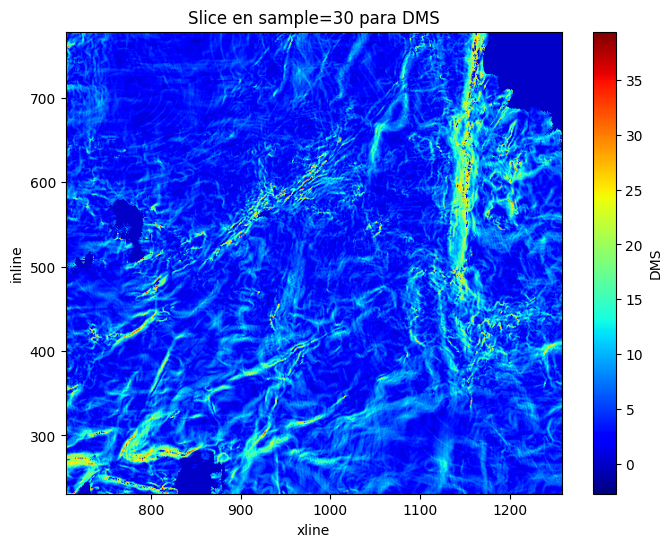

In [ ]:
Slice(DSEGY_df, 30, 'DMS')

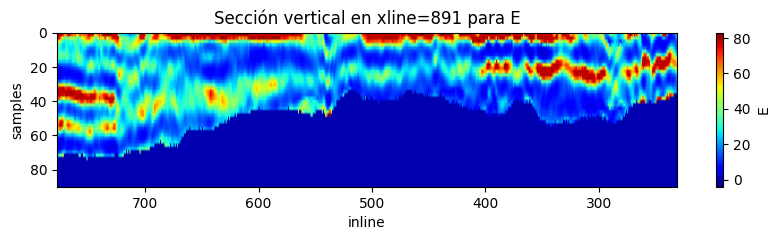

In [ ]:
Xline(DSEGY_df, 891, 'E')

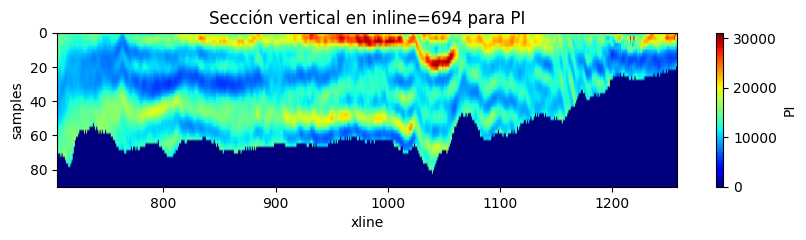

In [ ]:
Inline(DSEGY_df, 694, 'PI')

# Salvar Xarray.Dataset en formato NETCDF5

In [ ]:

#Salvar el dataframe primero a Xarray y finalmente a NETCDF5
DF_Xarray_NETCDF5(DSEGY_df, salida="/content/datos_yacimiento.nc")



# Lectura de Xarray.Dataset en formato NETCDF5

En caso de no contar con nuevos archivos SGY, se pude iniciar con los datos en formato NETCDF5

In [ ]:
# Cargar el archivo netCDF

file_path = "/content/datos_yacimiento.nc"
DSEGY_xr = xr.open_dataset(file_path, engine="h5netcdf")
DSEGY_xr.head()


<xarray.Dataset> Size: 10kB
Dimensions:     (inline: 5, xline: 5, samples: 5)
Coordinates:
  * inline      (inline) int16 10B 231 232 233 234 235
  * xline       (xline) int16 10B 705 706 707 708 709
  * samples     (samples) float32 20B 0.0 2.0 4.0 6.0 8.0
Data variables: (12/20)
    PI          (inline, xline, samples) float32 500B ...
    SI          (inline, xline, samples) float32 500B ...
    VpVs        (inline, xline, samples) float32 500B ...
    SWEETNESS   (inline, xline, samples) float32 500B ...
    DMS         (inline, xline, samples) float32 500B ...
    CALCITA     (inline, xline, samples) float32 500B ...
    ...          ...
    E           (inline, xline, samples) float32 500B ...
    PHIE        (inline, xline, samples) float32 500B ...
    PERM        (inline, xline, samples) float32 500B ...
    DENSIDAD    (inline, xline, samples) float32 500B ...
    SW          (inline, xline, samples) float32 500B ...
    TOC         (inline, xline, samples) float32 500B ...

In [ ]:
DSEGY_df = DSEGY_xr.to_dataframe().reset_index()
DSEGY_df.head()

,inline,xline,samples,PI,SI,VpVs,SWEETNESS,DMS,CALCITA,VSH,...,RP,LAME,K,G,E,PHIE,PERM,DENSIDAD,SW,TOC
0,231,705,0.0,16630.753906,8045.394531,2.061172,101.334763,6.565010,0.722984,0.269904,...,0.396285,47.625931,56.091354,12.698073,35.357803,0.088801,0.901127,2.581100,0.725315,0.014938
1,231,705,2.0,13360.980469,5546.992188,2.418441,33.454102,6.404507,0.721193,0.297643,...,0.400881,54.817566,63.841904,13.536562,37.946274,0.081351,0.796433,2.439180,0.691176,0.017587
2,231,705,4.0,14223.359375,5786.347656,2.457029,4.149960,6.224216,0.721604,0.290706,...,0.401325,61.574753,71.664673,15.134938,42.413849,0.083209,0.821861,2.475288,0.699705,0.016939
3,231,705,6.0,15220.949219,6178.382812,2.463624,-140.690903,5.729417,0.721654,0.292190,...,0.408764,62.841263,72.192444,14.026730,39.522247,0.082829,0.819260,2.519565,0.697910,0.017020
4,231,705,8.0,15131.511719,5944.402344,2.545372,-32.959305,9.642485,0.721044,0.293192,...,0.417018,63.110016,71.483154,12.559543,35.593292,0.082490,0.804238,2.521514,0.696560,0.017344


In [ ]:
DSEGY_dfm = DSEGY_df.set_index(["inline", "xline", "samples"])
DSEGY_dfm.head()

PI           SI      VpVs   SWEETNESS  \
inline xline samples                                                    
231    705   0.0      16630.753906  8045.394531  2.061172  101.334763   
             2.0      13360.980469  5546.992188  2.418441   33.454102   
             4.0      14223.359375  5786.347656  2.457029    4.149960   
             6.0      15220.949219  6178.382812  2.463624 -140.690903   
             8.0      15131.511719  5944.402344  2.545372  -32.959305   

                           DMS   CALCITA       VSH        BA  LAMBDA-RHO  \
inline xline samples                                                       
231    705   0.0      6.565010  0.722984  0.269904  0.901476  146.907776   
             2.0      6.404507  0.721193  0.297643  0.444463  116.955917   
             4.0      6.224216  0.721604  0.290706  0.442603  135.564087   
             6.0      5.729417  0.721654  0.292190  0.496882  155.224014   
             8.0      9.642485  0.721044  0.293192  0.439566  158.320908   

                         MU-RHO        RP       LAME          K          G  \
inline xline samples                                                         
231    705   0.0      31.056732  0.396285  47.625931  56.091354  12.698073   
             2.0      33.522903  0.400881  54.817566  63.841904  13.536562   
             4.0      38.137558  0.401325  61.574753  71.664673  15.134938   
             6.0      35.342621  0.408764  62.841263  72.192444  14.026730   
             8.0      31.547928  0.417018  63.110016  71.483154  12.559543   

                              E      PHIE      PERM  DENSIDAD        SW  \
inline xline samples                                                      
231    705   0.0      35.357803  0.088801  0.901127  2.581100  0.725315   
             2.0      37.946274  0.081351  0.796433  2.439180  0.691176   
             4.0      42.413849  0.083209  0.821861  2.475288  0.699705   
             6.0      39.522247  0.082829  0.819260  2.519565  0.697910   
             8.0      35.593292  0.082490  0.804238  2.521514  0.696560   

                           TOC  
inline xline samples            
231    705   0.0      0.014938  
             2.0      0.017587  
             4.0      0.016939  
             6.0      0.017020  
             8.0      0.017344

# Exploración de Datos

El Análisis Exploratorio de los Datos (EDA), se calcularon las estadísticas, histogramas y diagrama de bigote para cada variable, con el fin de conocer las distribuciones e identificar valores anómalos. De este primer análisis se identifica que todas las variables tienen muchos valores de cero.  Todas las variables son en formato float y solo las variables inline y xline son enteros

In [ ]:
estadisticas = DSEGY_df.describe()
print(estadisticas)

             inline         xline       samples            PI            SI  \
count  1.396523e+07  1.396523e+07  1.396523e+07  1.396523e+07  1.396523e+07   
mean   5.045000e+02  9.815000e+02  4.500000e+01  7.058700e+03  2.728043e+03   
std    1.581937e+02  1.599258e+02  2.650906e+01  6.669211e+03  2.940444e+03   
min    2.310000e+02  7.050000e+02  0.000000e+00  0.000000e+00 -1.048121e+03   
25%    3.677500e+02  8.430000e+02  2.200000e+01  0.000000e+00  0.000000e+00   
50%    5.045000e+02  9.815000e+02  4.500000e+01  8.980254e+03  2.846506e+03   
75%    6.412500e+02  1.120000e+03  6.800000e+01  1.256195e+04  4.731785e+03   
max    7.780000e+02  1.258000e+03  9.000000e+01  3.366115e+04  1.703479e+04   

               VpVs     SWEETNESS           DMS       CALCITA           VSH  \
count  1.396523e+07  1.396523e+07  1.396523e+07  1.396523e+07  1.396523e+07   
mean   1.525108e+00 -4.393886e+00  2.862126e+00  3.878235e-01  1.875850e-01   
std    1.429082e+00  1.904724e+02  3.973113e+00  3.

Columnas: Index(['inline', 'xline', 'samples', 'PI', 'SI', 'VpVs', 'SWEETNESS', 'DMS',
       'CALCITA', 'VSH', 'BA', 'LAMBDA-RHO', 'MU-RHO', 'RP', 'LAME', 'K', 'G',
       'E', 'PHIE', 'PERM', 'DENSIDAD', 'SW', 'TOC'],
      dtype='object')


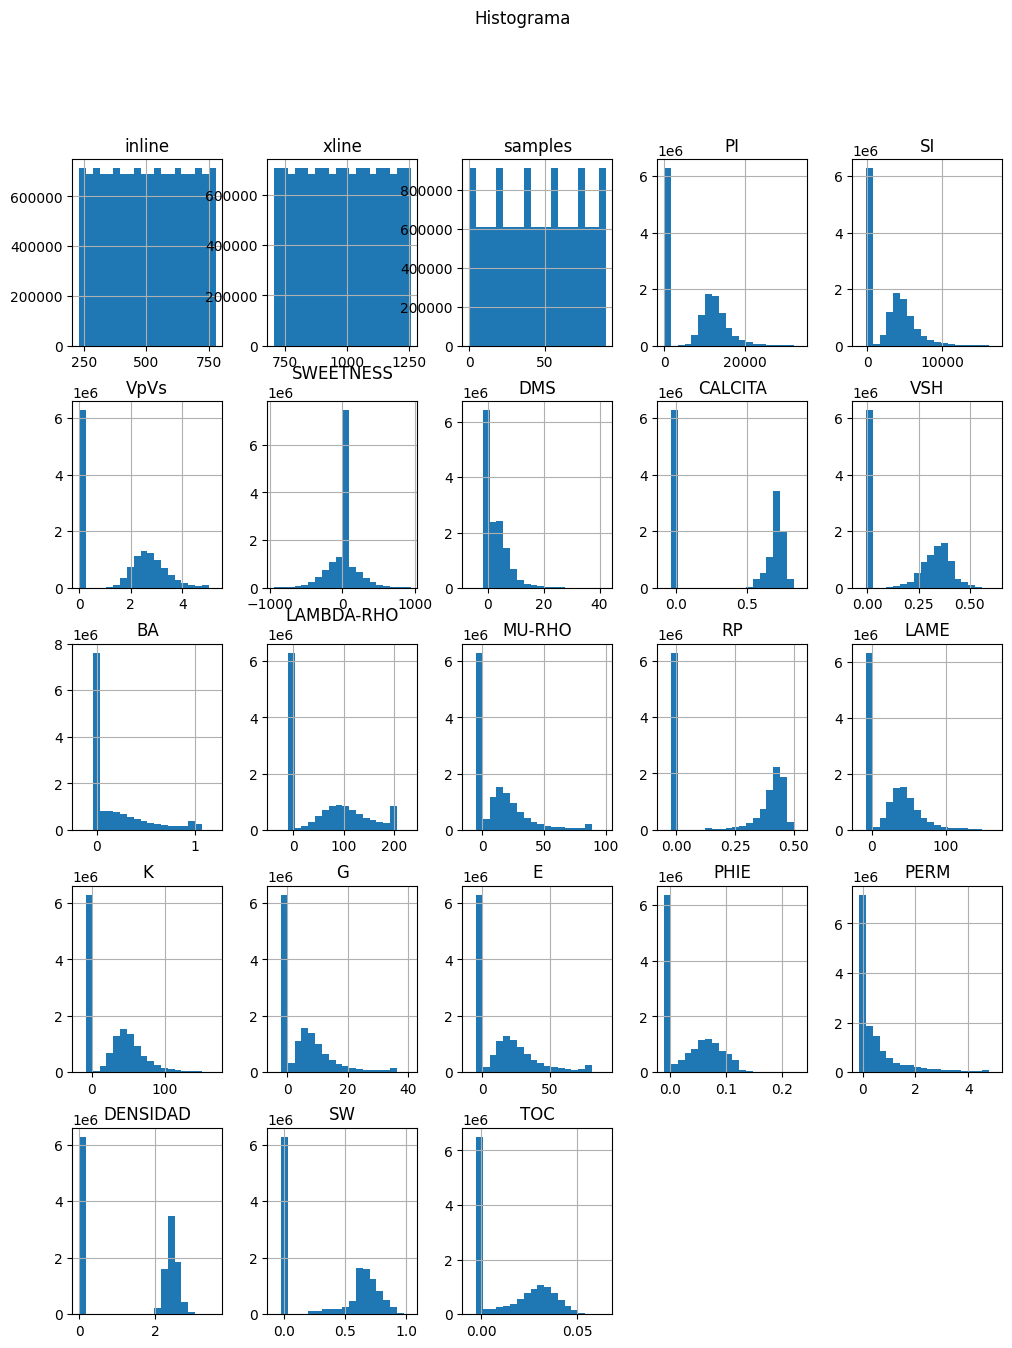

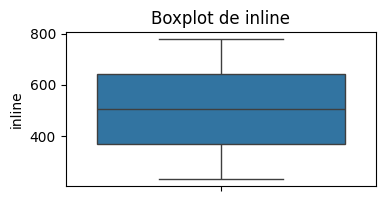

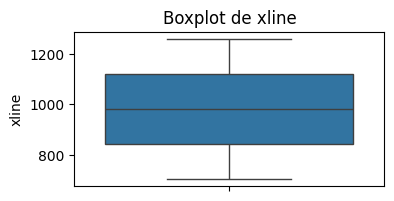

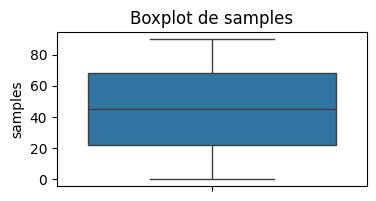

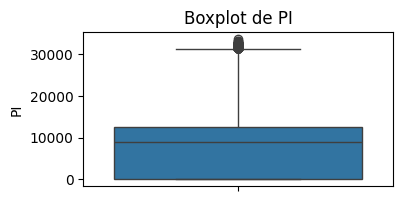

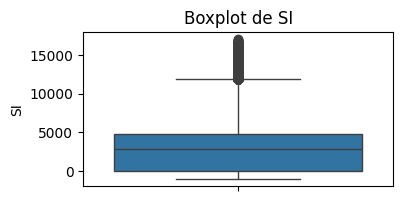

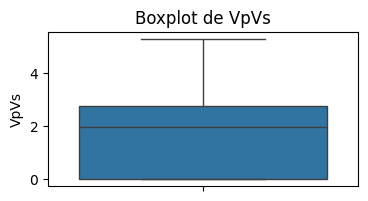

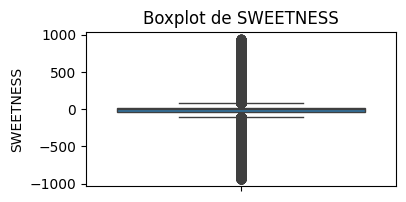

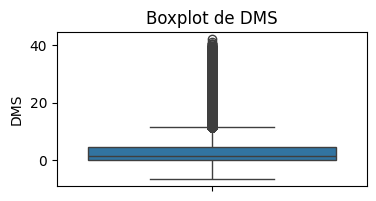

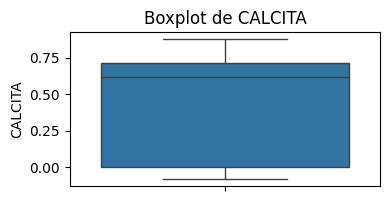

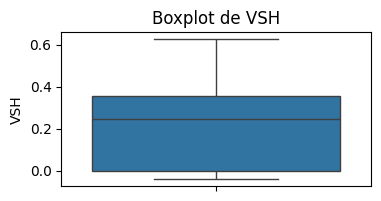

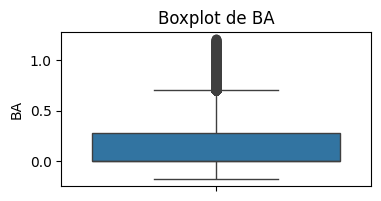

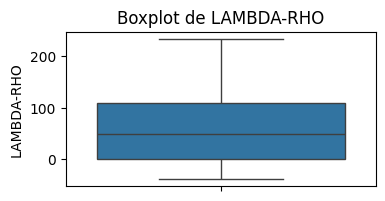

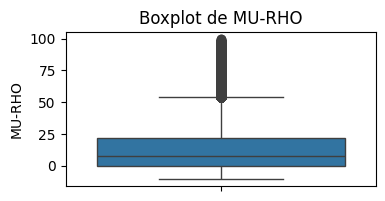

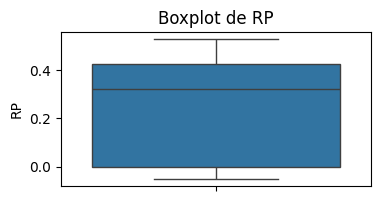

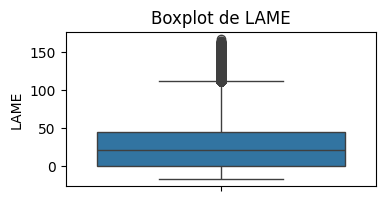

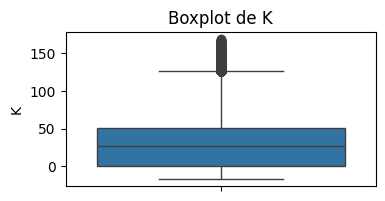

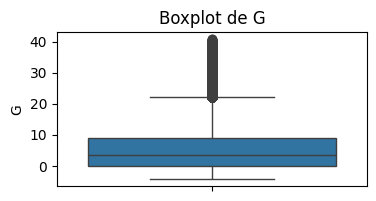

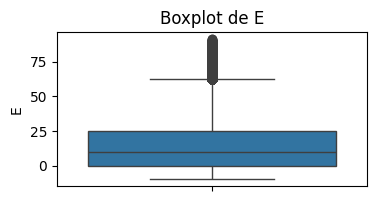

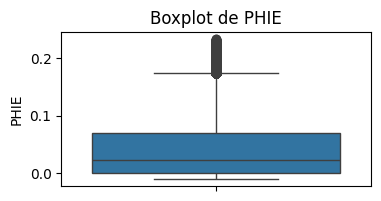

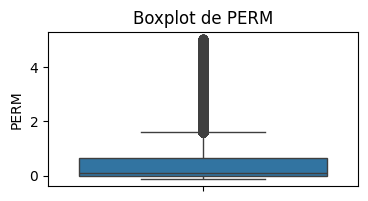

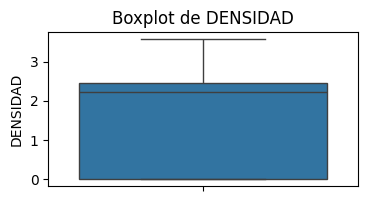

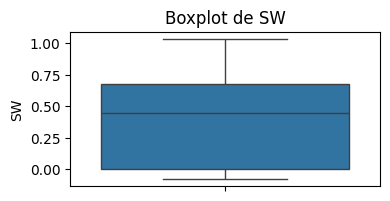

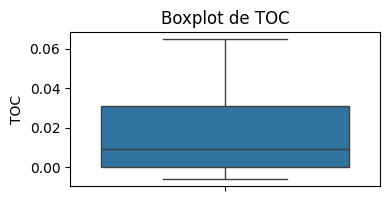

In [ ]:
# Columnas numéricas
numeric_cols = DSEGY_df.select_dtypes(include=np.number).columns
print("Columnas:", numeric_cols)

# Histogramas
DSEGY_df[numeric_cols].hist(figsize=(12,15), bins=20)
plt.suptitle("Histograma")
plt.show()

# Boxplots
for col in numeric_cols:
    plt.figure(figsize=(4,2))
    sns.boxplot(y=DSEGY_df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

# Limpieza de datos y control de calidad

La limpieza de los datos, consistió en eliminar los valores de las propiedades que, debido a la transformación de SEGY a un DataFrame, deberían ser valores Nulos (Nan) y que se pasaron como valor de Ceros (0). Para ello es que se eligió la variable DENSIDAD, la cual debe contener solo valores mayores a 0, de hecho esta variable el valor más pequeño corresponde a 1.6 (cm/g3). La variable MASK, se creó para que valores más pequeños al mínimo de la DENSIDAD fueran Nulos y cualquier otro valor fuera 1, la cual se multiplico por todas las variables.

El siguiente paso fue el de aplicar una reclasificación para los valores mínimos y máximo de cada variable, con ello se eliminan los valores anómalos de cada variable

In [ ]:
# Crear MASK a partir de DENSIDAD
DSEGY_df["MASK"] = np.where(DSEGY_df["DENSIDAD"] < 1.6, np.nan, 1)

# Ajustar MASK cuando samples == 0 (forzar a 1 incluso si era NaN)
DSEGY_df.loc[DSEGY_df["samples"] == 0, "MASK"] = 1

# Ver resumen
print(DSEGY_df["MASK"].describe())


count    7687720.0
mean           1.0
std            0.0
min            1.0
25%            1.0
50%            1.0
75%            1.0
max            1.0
Name: MASK, dtype: float64


In [ ]:
# Seleccionar todas las columnas excepto la del multiplicador
columnas_a_multiplicar = DSEGY_df.columns.difference(['MASK'])

# Multiplicar
DSEGY_df[columnas_a_multiplicar] = DSEGY_df[columnas_a_multiplicar].multiply(DSEGY_df['MASK'], axis=0)

print(DSEGY_df)

          inline  xline  samples            PI           SI      VpVs  \
0          231.0  705.0      0.0  16630.753906  8045.394531  2.061172   
1          231.0  705.0      2.0  13360.980469  5546.992188  2.418441   
2          231.0  705.0      4.0  14223.359375  5786.347656  2.457029   
3          231.0  705.0      6.0  15220.949219  6178.382812  2.463624   
4          231.0  705.0      8.0  15131.511719  5944.402344  2.545372   
...          ...    ...      ...           ...          ...       ...   
13965227     NaN    NaN      NaN           NaN          NaN       NaN   
13965228     NaN    NaN      NaN           NaN          NaN       NaN   
13965229     NaN    NaN      NaN           NaN          NaN       NaN   
13965230     NaN    NaN      NaN           NaN          NaN       NaN   
13965231     NaN    NaN      NaN           NaN          NaN       NaN   

           SWEETNESS       DMS   CALCITA       VSH  ...       LAME          K  \
0         101.334763  6.565010  0.722984  

In [ ]:
estadisticas2 = DSEGY_df.describe()
print(estadisticas2)

             inline         xline       samples            PI            SI  \
count  7.687720e+06  7.687720e+06  7.687720e+06  7.687720e+06  7.687720e+06   
mean   5.161766e+02  9.780912e+02  2.560966e+01  1.282258e+04  4.955658e+03   
std    1.613058e+02  1.563154e+02  1.666085e+01  3.575264e+03  2.065819e+03   
min    2.310000e+02  7.050000e+02  0.000000e+00  4.853582e+02 -1.048121e+03   
25%    3.740000e+02  8.430000e+02  1.200000e+01  1.053367e+04  3.631541e+03   
50%    5.220000e+02  9.800000e+02  2.400000e+01  1.224228e+04  4.553422e+03   
75%    6.610000e+02  1.109000e+03  3.800000e+01  1.435898e+04  5.762806e+03   
max    7.780000e+02  1.258000e+03  8.200000e+01  3.366115e+04  1.703479e+04   

               VpVs     SWEETNESS           DMS       CALCITA           VSH  \
count  7.687720e+06  7.687720e+06  7.687720e+06  7.687720e+06  7.687720e+06   
mean   2.770455e+00 -7.981739e+00  5.199235e+00  7.045048e-01  3.407599e-01   
std    6.758539e-01  2.580224e+02  3.902378e+00  5.

Columnas: Index(['inline', 'xline', 'samples', 'PI', 'SI', 'VpVs', 'SWEETNESS', 'DMS',
       'CALCITA', 'VSH', 'BA', 'LAMBDA-RHO', 'MU-RHO', 'RP', 'LAME', 'K', 'G',
       'E', 'PHIE', 'PERM', 'DENSIDAD', 'SW', 'TOC', 'MASK'],
      dtype='object')


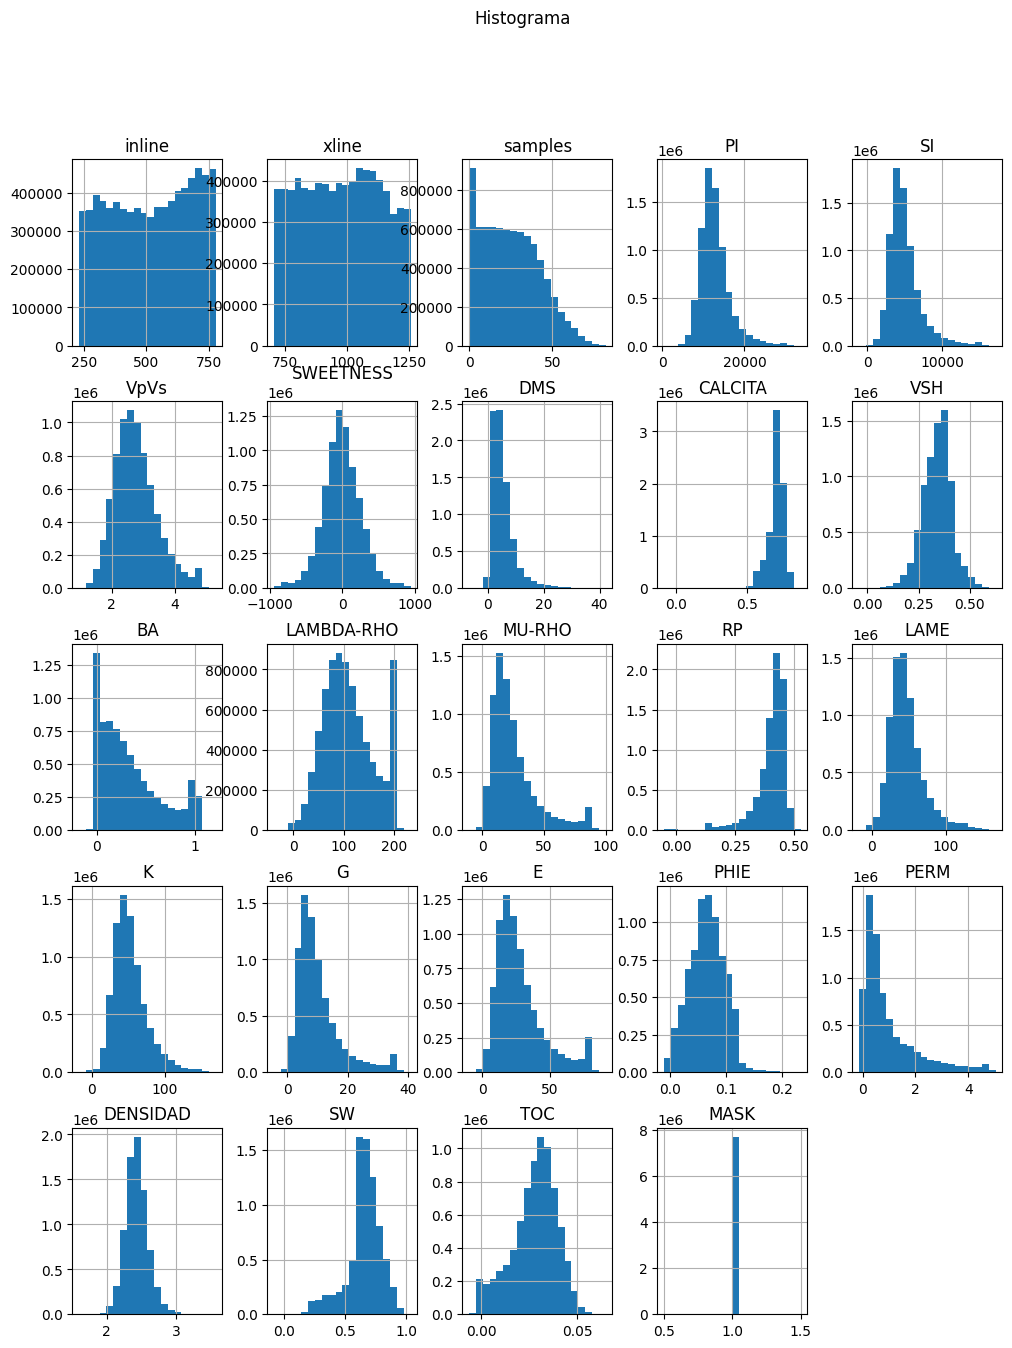

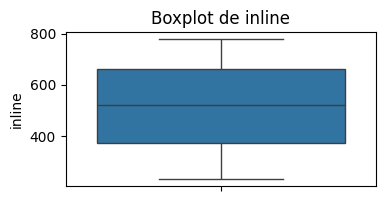

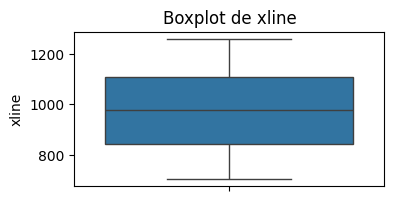

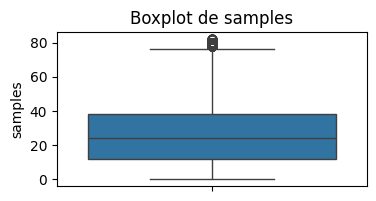

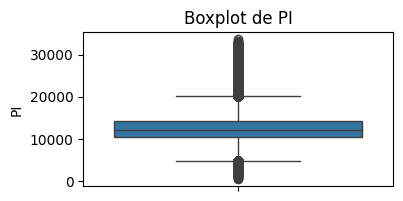

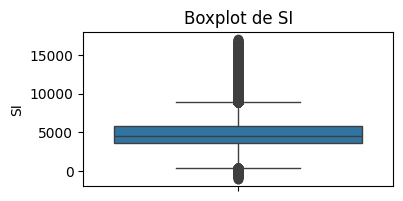

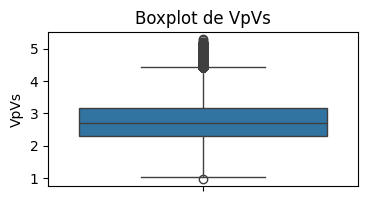

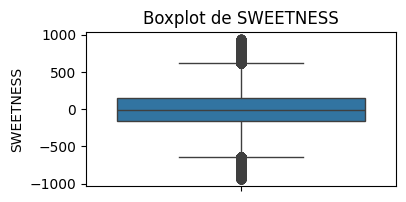

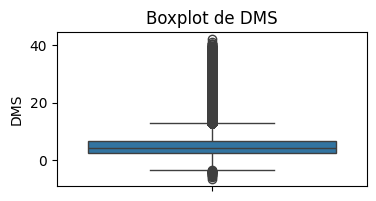

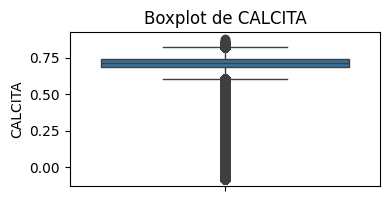

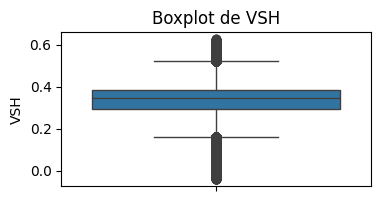

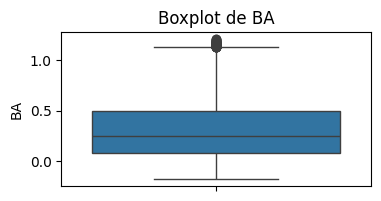

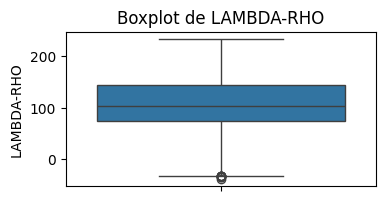

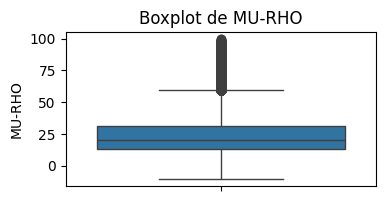

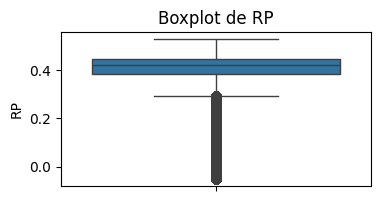

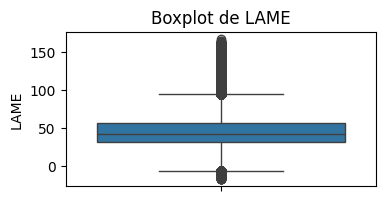

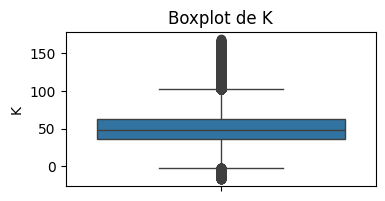

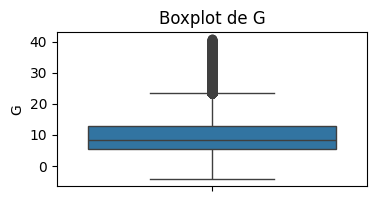

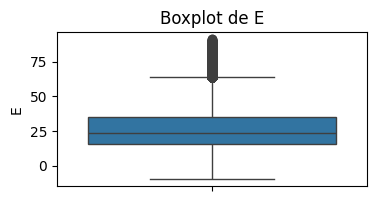

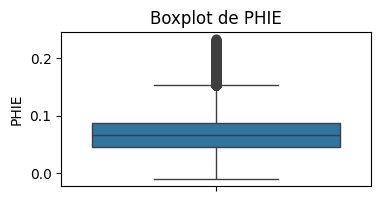

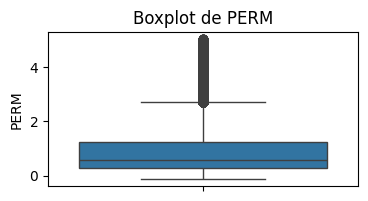

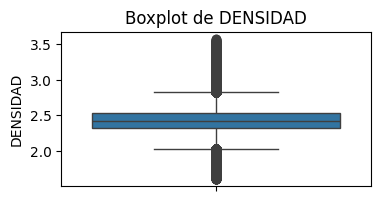

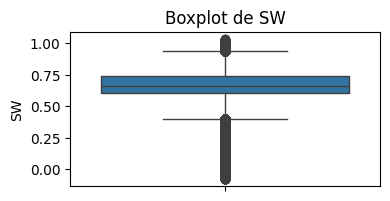

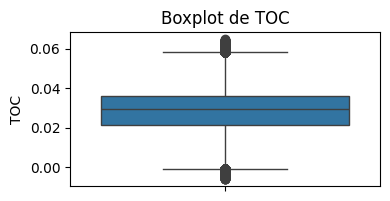

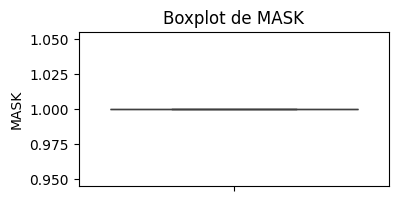

In [ ]:
# Columnas numéricas
numeric_cols = DSEGY_df.select_dtypes(include=np.number).columns
print("Columnas:", numeric_cols)

# Histogramas
DSEGY_df[numeric_cols].hist(figsize=(12,15), bins=20)
plt.suptitle("Histograma")
plt.show()

# Boxplots
for col in numeric_cols:
    plt.figure(figsize=(4,2))
    sns.boxplot(y=DSEGY_df[col])
    plt.title(f"Boxplot de {col}")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
# Eliminar los valores minimos y maximos de cada propiedad
DSEGY_df["BA"] = DSEGY_df["BA"].mask(DSEGY_df["BA"] < 0, 0)
DSEGY_df["BA"] = DSEGY_df["BA"].mask(DSEGY_df["BA"] > 1, 1)
DSEGY_df["CALCITA"] = DSEGY_df["CALCITA"].mask(DSEGY_df["CALCITA"] < 0.00225, 0.00225)
DSEGY_df["DENSIDAD"] = DSEGY_df["DENSIDAD"].mask(DSEGY_df["DENSIDAD"] < 1.6, 1.6)
DSEGY_df["DMS"] = DSEGY_df["DMS"].mask(DSEGY_df["DMS"] < 0, 0)
DSEGY_df["E"] = DSEGY_df["E"].mask(DSEGY_df["E"] < 1.09489, 1.09489)
DSEGY_df["G"] = DSEGY_df["G"].mask(DSEGY_df["G"] < 0.4, 0.4)
DSEGY_df["K"] = DSEGY_df["K"].mask(DSEGY_df["K"] < 1.3126, 1.3126)
DSEGY_df["LAMBDA-RHO"] = DSEGY_df["LAMBDA-RHO"].mask(DSEGY_df["LAMBDA-RHO"] < 0.00005, 0.00005)
DSEGY_df["MU-RHO"] = DSEGY_df["MU-RHO"].mask(DSEGY_df["MU-RHO"] < 0.64, 0.64)
DSEGY_df["LAME"] = DSEGY_df["LAME"].mask(DSEGY_df["LAME"] < 0.001, 0.001)
DSEGY_df["PERM"] = DSEGY_df["PERM"].mask(DSEGY_df["PERM"] < 0.0001, 0.0001)
DSEGY_df["PHIE"] = DSEGY_df["PHIE"].mask(DSEGY_df["PHIE"] < 0.00025, 0.00025)
DSEGY_df["PI"] = DSEGY_df["PI"].mask(DSEGY_df["PI"] < 310.7478, 310.7478)
DSEGY_df["RP"] = DSEGY_df["RP"].mask(DSEGY_df["RP"] < 0.14, 0.14)
DSEGY_df["SI"] = DSEGY_df["SI"].mask(DSEGY_df["SI"] < 12.03899, 12.03899)
DSEGY_df["SW"] = DSEGY_df["SW"].mask(DSEGY_df["SW"] < 0.07335, 0.07335)
DSEGY_df["SW"] = DSEGY_df["SW"].mask(DSEGY_df["SW"] > 1, 1)
#DSEGY_df["SWEETNESS"] = DSEGY_df["SWEETNESS"].mask(DSEGY_df["SWEETNESS"] < -800, -800)
DSEGY_df["TOC"] = DSEGY_df["TOC"].mask(DSEGY_df["TOC"] < 0, 0)
DSEGY_df["VSH"] = DSEGY_df["VSH"].mask(DSEGY_df["VSH"] < 0.00254, 0.00254)
DSEGY_df["VpVs"] = DSEGY_df["VpVs"].mask(DSEGY_df["VpVs"] < 1.3, 1.3)










In [ ]:
print(DSEGY_df.describe())

             inline         xline       samples            PI            SI  \
count  7.687720e+06  7.687720e+06  7.687720e+06  7.687720e+06  7.687720e+06   
mean   5.161766e+02  9.780912e+02  2.560966e+01  1.282258e+04  4.955662e+03   
std    1.613058e+02  1.563154e+02  1.666085e+01  3.575264e+03  2.065809e+03   
min    2.310000e+02  7.050000e+02  0.000000e+00  4.853582e+02  1.203899e+01   
25%    3.740000e+02  8.430000e+02  1.200000e+01  1.053367e+04  3.631541e+03   
50%    5.220000e+02  9.800000e+02  2.400000e+01  1.224228e+04  4.553422e+03   
75%    6.610000e+02  1.109000e+03  3.800000e+01  1.435898e+04  5.762806e+03   
max    7.780000e+02  1.258000e+03  8.200000e+01  3.366115e+04  1.703479e+04   

               VpVs     SWEETNESS           DMS       CALCITA           VSH  \
count  7.687720e+06  7.687720e+06  7.687720e+06  7.687720e+06  7.687720e+06   
mean   2.770467e+00 -7.981739e+00  5.199374e+00  7.045119e-01  3.407633e-01   
std    6.758274e-01  2.580224e+02  3.902158e+00  5.

A pesar de lo que pueda pensarse en el caso de un yacimiento, si bien esperamos que las propiedades tengan una distribución relativamente estable, es apreciable tener outliers alejados y que no sean muy simétricos, por que estos se pueden asociar a anomalías que corresponden a eventos geológicos. En geofísica lo que buscamos son anomalías que permitan diferenciarse del resto de zonas, pues eso puede indicar la presencia de hidrocarburos. Es decir, los hidrocarburos son una anomalía dentro de las rocas, y buscamos diferenciar estas zonas de las que no hay. Por lo que estos valores outliers pudiera ser la información que nos ayude a identificarlas

Columnas: Index(['inline', 'xline', 'samples', 'PI', 'SI', 'VpVs', 'SWEETNESS', 'DMS',
       'CALCITA', 'VSH', 'BA', 'LAMBDA-RHO', 'MU-RHO', 'RP', 'LAME', 'K', 'G',
       'E', 'PHIE', 'PERM', 'DENSIDAD', 'SW', 'TOC', 'MASK'],
      dtype='object')


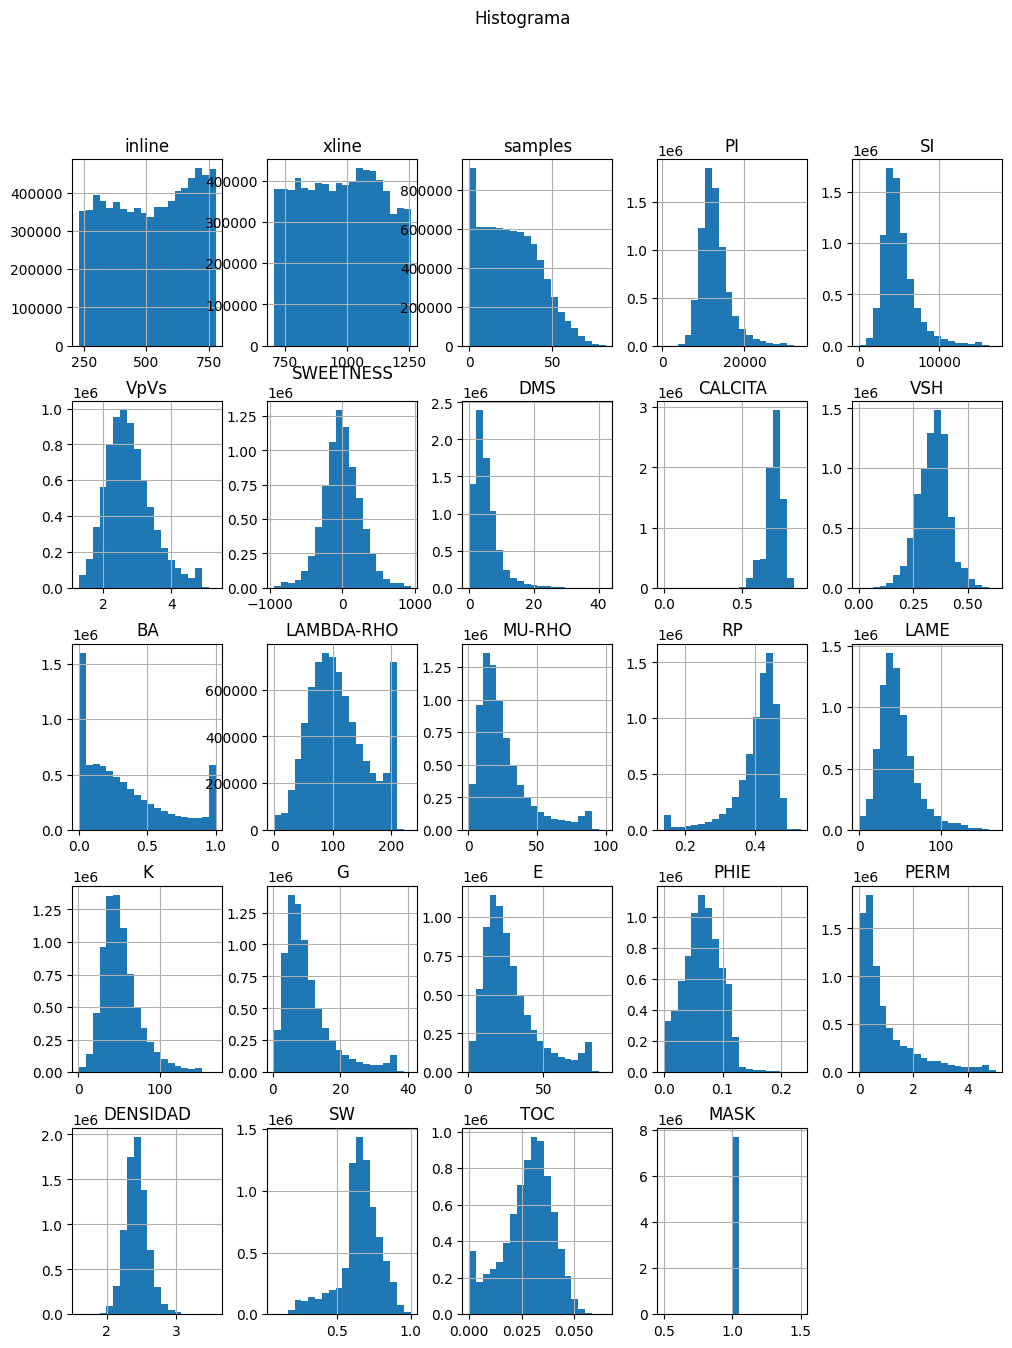

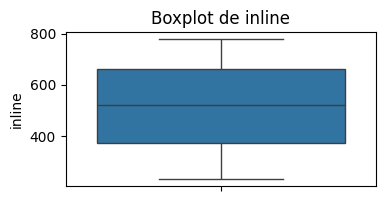

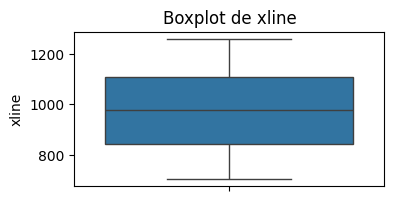

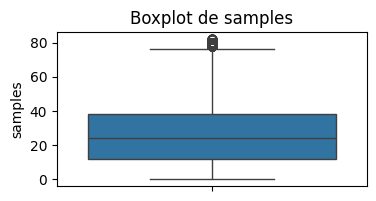

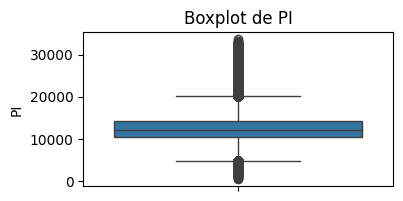

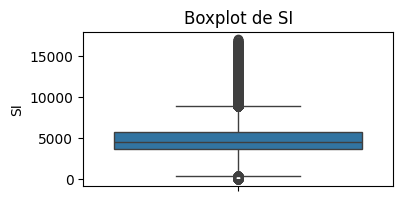

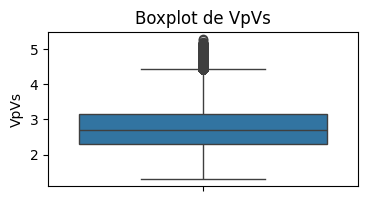

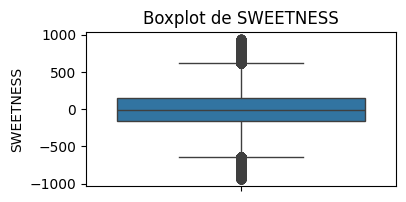

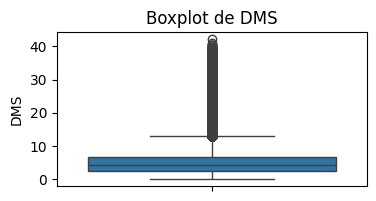

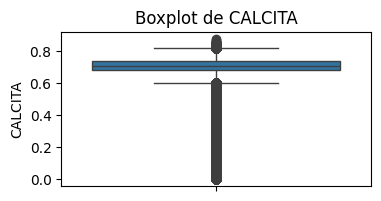

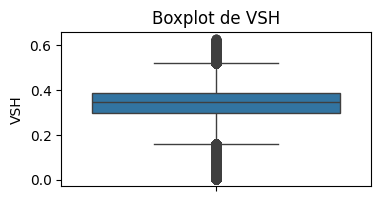

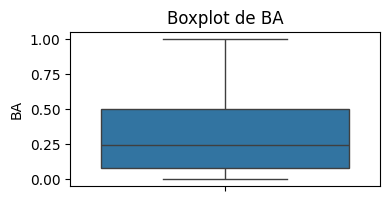

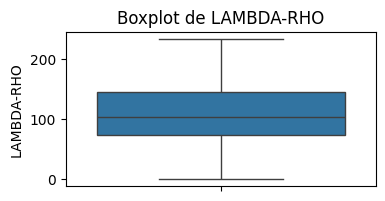

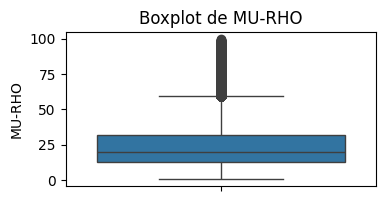

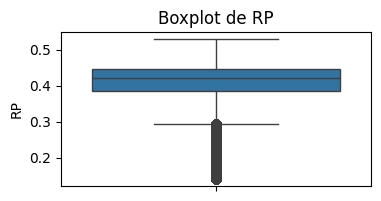

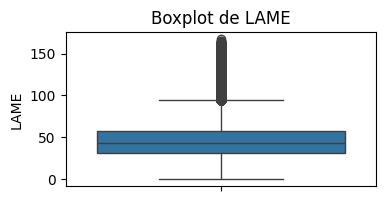

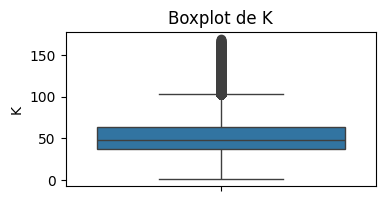

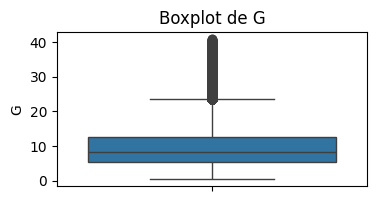

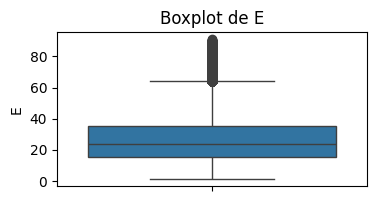

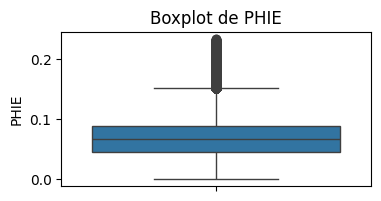

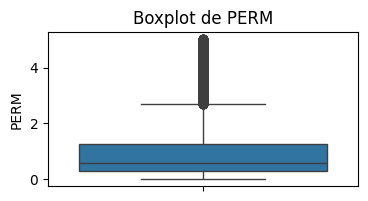

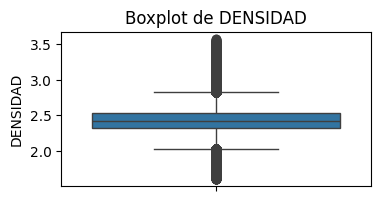

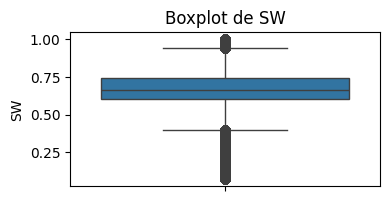

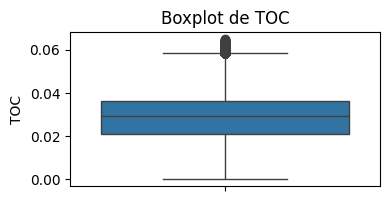

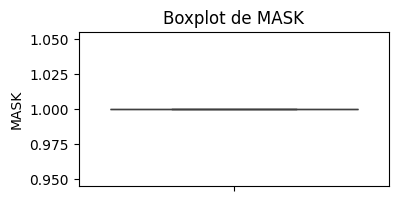

In [ ]:
# Columnas numéricas
numeric_cols = DSEGY_df.select_dtypes(include=np.number).columns
print("Columnas:", numeric_cols)

# Histogramas
DSEGY_df[numeric_cols].hist(figsize=(12,15), bins=20)
plt.suptitle("Histograma")
plt.show()

# Boxplots
for col in numeric_cols:
    plt.figure(figsize=(4,2))
    sns.boxplot(y=DSEGY_df[col])
    plt.title(f"Boxplot de {col}")
    plt.xticks(rotation=45)
    plt.show()

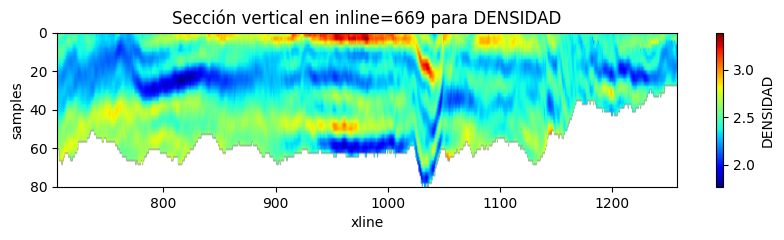

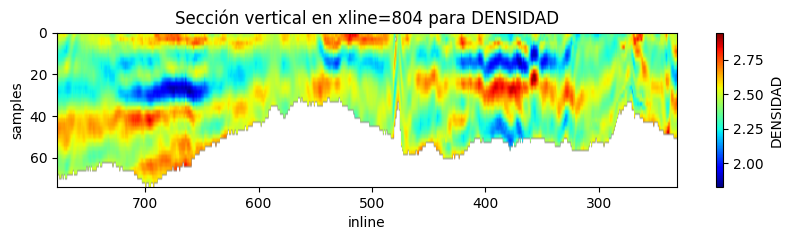

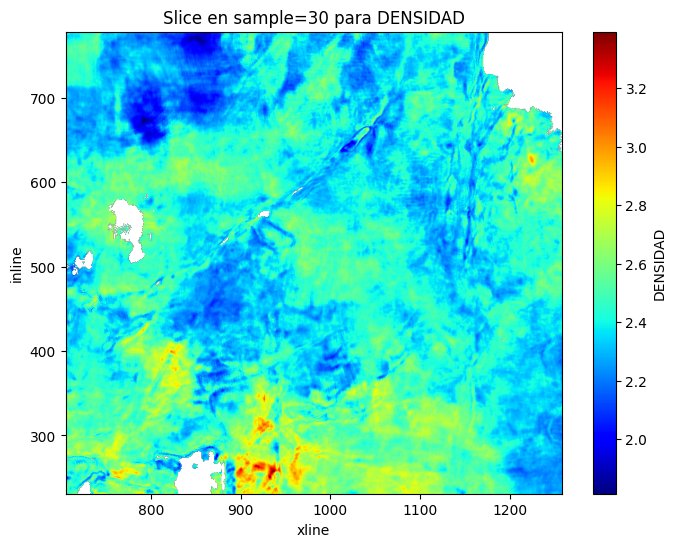

In [ ]:
Inline(DSEGY_df, 669, 'DENSIDAD')
Xline(DSEGY_df, 804, 'DENSIDAD')
Slice(DSEGY_df, 30, 'DENSIDAD')


In [ ]:
DSEGY_dfm = DSEGY_df.set_index(["inline", "xline", "samples"])
DSEGY_dfm.head()

PI           SI      VpVs   SWEETNESS  \
inline xline samples                                                    
231.0  705.0 0.0      16630.753906  8045.394531  2.061172  101.334763   
             2.0      13360.980469  5546.992188  2.418441   33.454102   
             4.0      14223.359375  5786.347656  2.457029    4.149960   
             6.0      15220.949219  6178.382812  2.463624 -140.690903   
             8.0      15131.511719  5944.402344  2.545372  -32.959305   

                           DMS   CALCITA       VSH        BA  LAMBDA-RHO  \
inline xline samples                                                       
231.0  705.0 0.0      6.565010  0.722984  0.269904  0.901476  146.907776   
             2.0      6.404507  0.721193  0.297643  0.444463  116.955917   
             4.0      6.224216  0.721604  0.290706  0.442603  135.564087   
             6.0      5.729417  0.721654  0.292190  0.496882  155.224014   
             8.0      9.642485  0.721044  0.293192  0.439566  158.320908   

                         MU-RHO  ...       LAME          K          G  \
inline xline samples             ...                                    
231.0  705.0 0.0      31.056732  ...  47.625931  56.091354  12.698073   
             2.0      33.522903  ...  54.817566  63.841904  13.536562   
             4.0      38.137558  ...  61.574753  71.664673  15.134938   
             6.0      35.342621  ...  62.841263  72.192444  14.026730   
             8.0      31.547928  ...  63.110016  71.483154  12.559543   

                              E      PHIE      PERM  DENSIDAD        SW  \
inline xline samples                                                      
231.0  705.0 0.0      35.357803  0.088801  0.901127  2.581100  0.725315   
             2.0      37.946274  0.081351  0.796433  2.439180  0.691176   
             4.0      42.413849  0.083209  0.821861  2.475288  0.699705   
             6.0      39.522247  0.082829  0.819260  2.519565  0.697910   
             8.0      35.593292  0.082490  0.804238  2.521514  0.696560   

                           TOC  MASK  
inline xline samples                  
231.0  705.0 0.0      0.014938   1.0  
             2.0      0.017587   1.0  
             4.0      0.016939   1.0  
             6.0      0.017020   1.0  
             8.0      0.017344   1.0  

[5 rows x 21 columns]

# Salvar Datos limpios

In [ ]:

#Salvar el dataframe primero a Xarray y finalmente a NETCDF5
DF_Xarray_NETCDF5(DSEGY_df, salida="/content/datos_yacimiento_clean.nc")



MultiIndex is not unique. Attempting to make it unique by dropping duplicates.


# Exportar resultados

In [ ]:
DSEGY_dfm = DSEGY_df.set_index(["inline", "xline", "samples"])
DSEGY_xr = DSEGY_dfm.to_xarray()
DSEGY_xr.head()
DSEGY_xr.seisio.to_segy(
    "V3D-out.segy", #Achivo de salida de datos,
    inline=17, #Ubicación del byte donde guardar inline
    xline=25, #Ubicación del byte donde guardar Xline
    data_var='MASK' # Nombre de la columna, variable a exportar.
)

# Bibliografía

•	Barry, K. M.; Cavers, D. A.; Kneale, C. W. 1975. "Recommended standards for digital tape formats". Geophysics 40 (2): 344–352. doi:10.1190/1.1440530.